In [ ]:
%pip install pandas numpy matplotlib

=== RANDOM ===
[(270000.0, 7.900000000000003, 102.72094728079284, 410), (276000.0, 7.3000000000000025, 101.43141042278893, 464), (289000.0, 6.600000000000003, 103.32510656491539, 473), (286000.0, 6.3000000000000025, 102.47098696738077, 431), (287000.0, 6.1000000000000005, 102.56271451619952, 191), (288000.0, 6.099999999999999, 101.76795647901292, 194), (150000.0, 5.900000000000001, 97.85366820794624, 110), (279000.0, 5.8999999999999995, 105.24417418103755, 253), (283000.0, 5.899999999999999, 100.00207963983736, 176), (280000.0, 5.699999999999998, 109.31570369567507, 242), (241000.0, 5.6000000000000005, 102.76273445971177, 207), (161000.0, 5.500000000000002, 100.02987495402897, 178), (260000.0, 5.500000000000002, 100.84526002036951, 278), (288000.0, 5.3000000000000025, 102.06492712288947, 326), (265000.0, 5.299999999999999, 103.12466653221009, 443), (277000.0, 5.199999999999999, 104.842279003484, 332), (281000.0, 5.199999999999999, 95.39300183064444, 364), (276000.0, 5.1, 99.86604957454

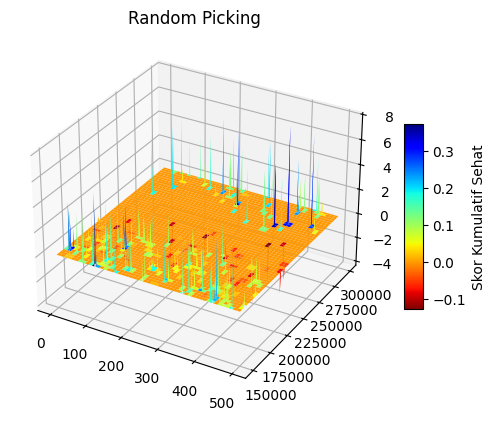

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NPM= 90        
np.random.seed(NPM)

makan =  pd.read_excel("https://github.com/adriann03/dataset_mahasiswa_matdis_a/raw/refs/heads/main/dataset_makanan_matdis.xlsx", engine='openpyxl')
# mohon ditambahkan (lagi) agar lebih beragam

budget= 1e6 #rupiah

wkenyang_base= 0.8
wrasa_base= 0.7
wsehat_base= 0.9 # simpangan lebih besar
wbosan_base= 0.2

skor_kumulatif= 0.0
SAMPLE_NUM= 500

sampleid= np.arange(0, 500)
# skor perorangan
skor= np.zeros(SAMPLE_NUM, dtype=np.double)
sisa= np.zeros(SAMPLE_NUM, dtype=np.double)
sehat= np.zeros(SAMPLE_NUM, dtype=np.double)
pilihankum= np.zeros(SAMPLE_NUM, dtype=np.double)

SISA_MININUM= 150e3
SISA_MAKSIMUM= 300e3
bin_sisa= np.arange(SISA_MININUM, SISA_MAKSIMUM, 1000)
resp_sehat= np.zeros((SAMPLE_NUM, len(bin_sisa)), dtype=np.double)
resp_pilih= np.zeros((SAMPLE_NUM, 62), dtype=np.double)

print("=== RANDOM ===")
for n in range(0, SAMPLE_NUM):
    budget=1e6
    skor_kumulatif= 0
    skor_sehat= 0
    
    for i in range(0, 31): # hari
        # makan pertama, pilih secara acak
        pilihan= np.random.randint(0, len(makan))
        # update weight factor
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base, scale=0.2)
        skor_kumulatif= skor_kumulatif + \
            w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget = budget - makan['harga'][pilihan]
        #print(f"hari {i} pagi: {makan['makanan'][pilihan]}") 
        resp_pilih[n][2*i]= pilihan
        
        # makan keduas
        pilihan= np.random.randint(0, len(makan))
        # update weight factor
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base+0.2, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base*2, scale=0.2)
        skor_kumulatif= skor_kumulatif + \
            w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget = budget - makan['harga'][pilihan]
        #print(f"hari {i} malam: {makan['makanan'][pilihan]}")    
        resp_pilih[n][2*i+1]= pilihan
    
    # print(f"skor: {skor_kumulatif}, sisa uang: {budget}")    
    sisa[n]= budget
    skor[n]= skor_kumulatif
    sehat[n]= skor_sehat
    # print(f"{n} skor sehat:{skor_sehat}")
    
    resp_sehat[n][ int((budget-SISA_MININUM)/1000)]= skor_sehat

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set_title("Random Picking")
Y, X = np.meshgrid(bin_sisa, sampleid)
# Colorize the surface using a colormap
surf = ax.plot_surface(X, Y, resp_sehat, 
                       cmap='jet_r',   # try 'plasma', 'coolwarm', etc.
                       edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Skor Kumulatif Sehat")

# plot yang ini barangkali butuh dipercantik

# TUGAS
# (1) cari pola makan mana saja yang menghasilkan nilai kumulatif kesehatan (resp_sehat) positif 
# (2) cari titik-titik dengan sisa uang bulanan positif dari (1)
# (3) cari titik dengan skor skumulatif terbesar (skor) di mana nilai kumulatif kesehatannya positif
# (4) tampikan jadwal makanan sesuai pilihan (resp_pilih)

values = []
for i in range(SAMPLE_NUM):
    max_value = resp_sehat[i][j]
    j_max = 0
    for j in range(len(bin_sisa)):
        if resp_sehat[i][j] > max_value:
            max_value = resp_sehat[i][j]
            j_max = j
        if j == len(bin_sisa) - 1:
            values.append((bin_sisa[j_max].item(), max_value.item(), skor[i].item(), i))
descending_sorted_values = sorted(values, key=lambda element: element[1], reverse=True)
print(descending_sorted_values)
print(resp_pilih[descending_sorted_values[0][3]])
for i in range(len(resp_pilih[descending_sorted_values[0][3]])):
    day = ["pagi", "malam"]
    print(f"Hari ke-{i//2 + 1} {day[i%2]}: {makan['makanan'][int(resp_pilih[descending_sorted_values[0][3]][i])]}")

In [138]:
arr = np.array([[3, 1, 2],
                [6, 5, 4],
                [9, 2, 8]])

sorted_arr_cols = np.sort(arr, axis=0)
print("Column-wise sorted array:\n", sorted_arr_cols)

Column-wise sorted array:
 [[3 1 2]
 [6 2 4]
 [9 5 8]]
